# Decision Trees: Learning to Ask the Right Questions

**DCS 404 · Data Science and Machine Learning**

---

Every model so far has been an equation. Linear regression drew a line, logistic regression bent that line
into a probability — but under the hood it was always *weights times features*, and explaining a prediction
meant talking about coefficients.

Today's model doesn't compute; it *asks questions*. Is the glucose level above 127? Is the petal shorter
than 2.5 cm? Each answer narrows things down, exactly like a game of twenty questions, until the model is
confident enough to commit to an answer. The result is a **decision tree** — a flowchart learned from data,
and the first model in this course that a domain expert can read top-to-bottom and *audit* without knowing
any mathematics.

That readability comes at a price, and the price is the theme of this module: **decision trees are
chronically prone to overfitting**. Left alone, a tree will keep asking ever-pickier questions until it has
memorized every quirk of the training set — the tree-shaped version of the degree-14 polynomial from the
Regularization module. So after building trees up (how they choose questions, how to grow one in
scikit-learn), we spend the second half reining them in: early stopping, its failure mode, and pruning.
We close by finishing the evaluation toolkit we started last module — multiclass metrics, ROC curves,
and AUC.

## How to work through this

The usual rhythm: run every code cell (`Shift + Enter`), study the output, *then* read the commentary.
Cells build on each other, so if something errors, run from the top.

The module is in three acts:

1. **Sections 1–4** build the machinery: what a tree is, how it measures the "quality" of a question
   (impurity), the growing algorithm, and trees in scikit-learn on the iris dataset.
2. **Sections 5–8** are the drama: watching a tree overfit a small noisy dataset, then two rescue
   strategies — early stopping (and the XOR problem that defeats it) and cost-complexity pruning.
3. **Sections 9–10** zoom out: the classic tree-building algorithms (ID3, C4.5, CART), and the missing
   pieces of classifier evaluation — multiclass F1 averaging, the ROC curve, and AUC — demonstrated on
   the diabetes dataset from the Logistic Regression module.

## Learning objectives

After completing this module you will be able to:

- Describe the anatomy of a decision tree (root, internal nodes, leaves, branches, depth) and trace a
  prediction through one by hand.
- Compute **Gini impurity** and **entropy** for a class distribution, and **information gain** for a
  split; explain why gain ratio corrects information gain's bias.
- Fit a `DecisionTreeClassifier`, visualize the fitted tree and its **axis-aligned decision boundary**,
  and interpret the information in each node.
- Demonstrate why fully grown trees **overfit**, using train/test accuracy gaps and decision-surface
  complexity.
- Apply the three main **early-stopping** controls (`max_depth`, `min_impurity_decrease`,
  `min_samples_split`) and explain, via the XOR problem, why early stopping can fail.
- Explain and apply **cost-complexity pruning**: the $\alpha$ trade-off, `cost_complexity_pruning_path`,
  and choosing the final tree with Occam's razor.
- Compare the classic tree **inducers** — ID3, C4.5, CART — and state which one scikit-learn implements.
- Evaluate multiclass classifiers with **macro / weighted / micro F1**, and binary classifiers with
  **precision–recall curves**, **ROC curves**, and **AUC**.

## Setup

Run this once. Libraries, the usual plotting style, and the diabetes dataset (which returns for the
ROC-curve finale in Section 10).

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import make_classification, load_iris
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import train_test_split
from sklearn.inspection import DecisionBoundaryDisplay
from sklearn.metrics import (accuracy_score, confusion_matrix, ConfusionMatrixDisplay,
                             classification_report, f1_score, roc_auc_score,
                             RocCurveDisplay, PrecisionRecallDisplay)

# A consistent look for every plot in this notebook
plt.rcParams.update({
    "figure.figsize": (7, 4.5),
    "figure.dpi": 110,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 11,
})
sns.set_palette("deep")
RANDOM_STATE = 12

# Load the Pima Indians Diabetes dataset (used in Section 10)
for candidate in [Path("data/diabetes.csv"),
                  Path("notebooks/data/diabetes.csv")]:
    if candidate.exists():
        diabetes = pd.read_csv(candidate)
        print(f"Loaded diabetes dataset from: {candidate}")
        break
else:
    raise FileNotFoundError("Could not find diabetes.csv. Expected it in a data/ folder next to the notebook.")

print(f"Shape: {diabetes.shape[0]} patients, {diabetes.shape[1]} columns")

Loaded diabetes dataset from: data/diabetes.csv
Shape: 768 patients, 9 columns


---
## 1. What is a decision tree?

A decision tree solves a complex problem the way people naturally do: **divide it into small questions and
answer them one at a time**. For a given input, the tree estimates the unknown property (the label) through
a cascade of simple tests.

Say we want a model that decides whether an animal is a **fish**. A biologist might reason: does it live in
water? If not — done, not a fish. If yes, we can't conclude yet (dolphins live in water too), so we ask a
sharper follow-up: can it *also* live outside water? Each question splits the world into smaller, purer
groups:

<div align="center">
<img src="resources/images/dt_fish_tree.png" width="720">

*Figure 1 — Growing a decision tree for fish classification: (a) start with a first test, (b) one answer
already gives a verdict, (c) the other answer needs a follow-up test.*
</div>

The vocabulary, reading Figure 1(c) top to bottom:

- **Root node** — where the first test happens (*Lives in water*). Every prediction starts here.
- **Internal (decision) nodes** — nodes that perform further tests (*Can live outside water*).
- **Leaf (terminal) nodes** — the green boxes; no more questions, just a **verdict** (*Fish* / *Not a fish*).
- **Branches** — the Yes/No arrows; each answer routes the sample down exactly one path.
- **Depth** — the length of the longest path from root to leaf (here: 2).

Here is a second tree, diagnosing a disease from symptoms — same anatomy, different domain:

<div align="center">
<img src="resources/images/dt_cough_fever_tree.png" width="520">

*Figure 2 — A diagnosis tree: two tests route every patient to one of three leaves.*
</div>

To classify a new sample, you *drop it in at the root* and follow the answers until it lands in a leaf.
That's the entire prediction algorithm — no arithmetic, just routing. The machine-learning question is:
**given a dataset, which questions should the tree ask, and in what order?** That is what the rest of the
module answers.

---
## 2. Impurity: how a tree scores its questions

A good question is one whose answers separate the classes well. After asking *Lives in water?*, the "No"
group is 100% not-fish — perfectly sorted. A useless question leaves each group as mixed as before. To
*learn* good questions, we need a number that measures "how mixed is this group?" That number is called
**impurity**, and there are two classic recipes.

### Gini impurity

The Gini impurity is the probability of *misclassifying* a randomly chosen sample from a group, if we
labelled it randomly according to the group's class proportions:

$$\text{Gini} = 1 - \sum_{i=1}^{c} P_i^{\,2}$$

where $c$ is the number of classes and $P_i$ is the fraction of samples belonging to class $i$. A pure
group scores 0; maximum mixing scores highest. Let's code it — three lines:

In [2]:
def compute_gini(class_counts):
    """Gini impurity from a list of per-class sample counts."""
    p = np.array(class_counts) / np.sum(class_counts)
    return 1 - np.sum(p ** 2)

# Sanity check: a pure node and a 50:50 node
print(f"Gini of [10, 0]: {compute_gini([10, 0]):.3f}")
print(f"Gini of [5, 5]:  {compute_gini([5, 5]):.3f}")

Gini of [10, 0]: 0.000
Gini of [5, 5]:  0.500


Now apply it to four different samples of fish-classification data:

<div align="center">
<img src="resources/images/dt_gini_table.png" width="560">

*Figure 3 — Four class distributions, from perfectly pure to perfectly mixed.*
</div>

In [3]:
class_distributions = [(10, 0), (1, 9), (7, 3), (5, 5)]

for dist in class_distributions:
    print(f"Fish = {dist[0]:2d}, Not a fish = {dist[1]}  →  Gini = {compute_gini(dist):.2f}")

Fish = 10, Not a fish = 0  →  Gini = 0.00
Fish =  1, Not a fish = 9  →  Gini = 0.18
Fish =  7, Not a fish = 3  →  Gini = 0.42
Fish =  5, Not a fish = 5  →  Gini = 0.50


Read the pattern: **a pure set has zero impurity; impurity peaks when the classes are evenly mixed**
(0.5 for two classes). In between, the more lopsided the distribution, the lower the impurity. The curve
below shows this for every possible class proportion:

<div align="center">
<img src="resources/images/dt_impurity_curve.png" width="380">

*Figure 4 — Impurity as a function of the class-A proportion: zero at the pure extremes, maximal at 50:50.*
</div>

### Entropy

The second classic impurity measure comes from information theory. **Entropy** quantifies the disorder in
a group:

$$\text{Entropy} = -\sum_{i=1}^{c} P_i \log_2 P_i$$

It behaves like Gini — 0 for pure groups, maximal (1 bit, for two classes) at 50:50 — and in practice the
two usually pick the same splits. Gini is marginally cheaper to compute (no logarithm), which is why it is
scikit-learn's default.

### From impurity to choosing a split: information gain

A split is good if the children are *purer than the parent*. **Information gain** makes that precise —
it is the impurity drop achieved by a split:

$$\text{Gain} = \text{Entropy}(\text{parent}) \;-\; \sum_{\text{children } k} \frac{m_k}{m}\,\text{Entropy}(\text{child}_k)$$

where each child's entropy is weighted by the fraction of samples $m_k/m$ that flow into it. (The same
recipe works with Gini in place of entropy.) The tree evaluates every candidate question and **keeps the
one with the largest gain**.

Let's work one example fully. A tiny loan dataset:

| ID | Is Married | Is House Owner | Will Repay Loan |
|---|---|---|---|
| 1 | false | true | **yes** |
| 2 | true | true | **yes** |
| 3 | true | false | **no** |
| 4 | true | false | **yes** |

Candidate question: *Is House Owner?* It sends rows 1–2 (both **yes**) one way and rows 3–4 (one **yes**,
one **no**) the other.

In [4]:
def compute_entropy(class_counts):
    """Entropy (bits) from a list of per-class sample counts."""
    p = np.array(class_counts) / np.sum(class_counts)
    p = p[p > 0]                       # 0 log 0 = 0, so drop empty classes
    return -np.sum(p * np.log2(p)) + 0.0   # +0.0 turns -0.0 into 0.0

# Parent: 3 'yes', 1 'no'
parent = compute_entropy([3, 1])

# Split on 'Is House Owner': owners -> [2 yes, 0 no], non-owners -> [1 yes, 1 no]
owners     = compute_entropy([2, 0])
non_owners = compute_entropy([1, 1])
weighted_children = (2/4) * owners + (2/4) * non_owners

print(f"Entropy(parent)        = {parent:.3f} bits")
print(f"Entropy(owners)        = {owners:.3f} bits")
print(f"Entropy(non-owners)    = {non_owners:.3f} bits")
print(f"Weighted child entropy = {weighted_children:.3f} bits")
print(f"Information gain       = {parent - weighted_children:.3f} bits")

Entropy(parent)        = 0.811 bits
Entropy(owners)        = 0.000 bits
Entropy(non-owners)    = 1.000 bits
Weighted child entropy = 0.500 bits
Information gain       = 0.311 bits


A positive gain: asking about home ownership genuinely sorts the borrowers. The tree would compare this
gain against the *Is Married* split (try it — Exercise 1) and keep the better question.

### A flaw, and its fix: gain ratio

Information gain has a bias: it *loves attributes with many distinct values*. The pathological case is the
**ID column** — splitting on it creates one child per row, every child trivially pure, information gain
maximal:

<div align="center">
<img src="resources/images/dt_id_split.png" width="640">

*Figure 5 — Splitting on ID: four "perfectly pure" children, and a model that has learned precisely
nothing.*
</div>

An ID-split generalizes to new data not at all — it's memorization dressed up as purity (a first taste of
this module's overfitting theme). The fix is the **gain ratio**: divide the information gain by the *split
information* — the entropy of the split itself, which is large when a question shatters the data into many
small pieces:

$$\text{Gain ratio} = \frac{\text{Information gain}}{-\sum_k \frac{m_k}{m}\log_2 \frac{m_k}{m}}$$

Many-way splits pay a large denominator, so the ID column stops looking clever.

### Seeing a split chosen

Here is the whole machinery at work on real-looking data. Two candidate splits of the same parent node —
a vertical cut on $x_0$ and a horizontal cut on $x_1$ — with the class histograms of the resulting
children:

<div align="center">
<img src="resources/images/dt_split_selection.png" width="680">

*Figure 6 — (a) the parent node's data, evenly mixed across three classes. (b) A vertical split isolates
the blue class perfectly — weighted Gini 0.334. (c) A horizontal split leaves both children mixed —
weighted Gini 0.532. The tree picks (b).*
</div>

One last note: nothing here is classification-specific. For **regression trees**, swap the impurity metric
for MSE/variance of the target within a node — the machinery is otherwise identical (that is
scikit-learn's `DecisionTreeRegressor`).

---
## 3. The growing algorithm

All the pieces are on the table; the algorithm that assembles them is disarmingly simple — **recursive
partitioning**, greedy at every step:

1. Start at the root with the full training set.
2. **If** all samples in the node share one class (the node is *pure*), or another stopping criterion is
   met — make it a **leaf**, labelled with the majority class. Stop.
3. **Otherwise**, evaluate every candidate split (every feature, every threshold), and keep the one with
   the best impurity reduction.
4. Split the data into children accordingly, and **recurse** into each child (go to 2).

Two properties of this procedure will matter enormously in Section 5:

- It is **greedy** — it picks the best *immediate* split, never looking ahead. (Remember this when we hit
  the XOR problem.)
- With no stopping criterion beyond purity, **it doesn't stop until every leaf is pure** — even if
  achieving purity means carving out a leaf for every noisy, mislabelled straggler in the training set.

---
## 4. Decision trees in scikit-learn

Scikit-learn implements all of this in `DecisionTreeClassifier` (and `DecisionTreeRegressor` for continuous
targets), with the same `fit`/`predict` interface as every model so far. We'll use the **iris dataset** —
150 flowers, 4 measurements (sepal length & width, petal length & width), 3 species (*setosa*,
*versicolor*, *virginica*).

Test accuracy: 93.3%


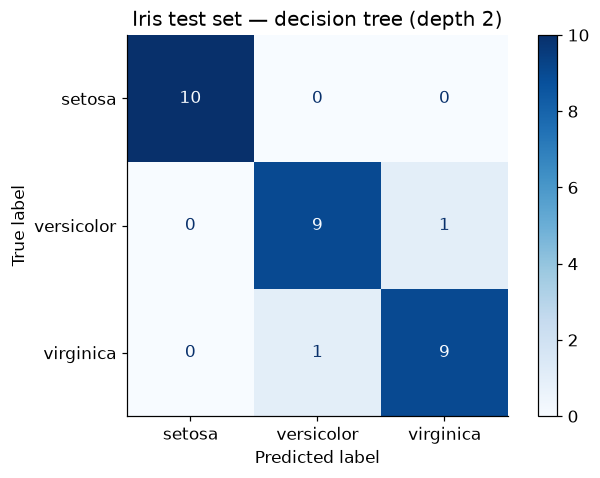

In [5]:
iris = load_iris()
X_ir, y_ir = iris.data, iris.target

X_ir_train, X_ir_test, y_ir_train, y_ir_test = train_test_split(
    X_ir, y_ir, test_size=0.2, random_state=42, stratify=y_ir)

tree_iris = DecisionTreeClassifier(max_depth=2, random_state=42)
tree_iris.fit(X_ir_train, y_ir_train)

y_ir_pred = tree_iris.predict(X_ir_test)
print(f"Test accuracy: {accuracy_score(y_ir_test, y_ir_pred):.1%}")

ConfusionMatrixDisplay.from_estimator(tree_iris, X_ir_test, y_ir_test,
                                      display_labels=iris.target_names, cmap="Blues")
plt.title("Iris test set — decision tree (depth 2)")
plt.grid(False)
plt.show()

A depth-2 tree — at most two questions per flower — already classifies nearly every test sample. Notice
*setosa* is predicted perfectly: its flowers form a tight, well-separated cluster, so a single question
isolates them. The rare confusions are all between *versicolor* and *virginica*, whose measurements
overlap.

### Reading the tree itself

Here is the model's biggest selling point: we can simply *draw it and read it*. Scikit-learn ships a
`plot_tree` function.

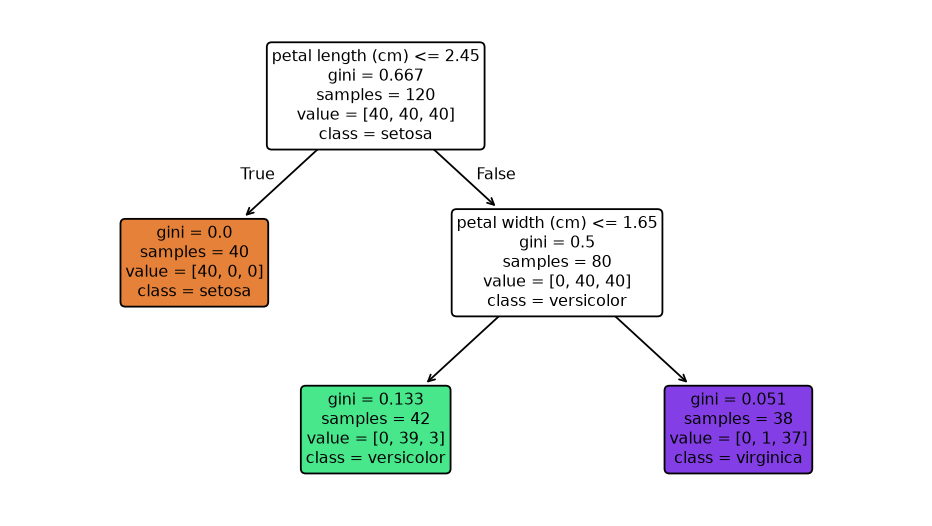

In [6]:
fig, ax = plt.subplots(figsize=(9, 5), dpi=130)
plot_tree(tree_iris,
          feature_names=iris.feature_names,
          class_names=iris.target_names,
          filled=True, rounded=True, fontsize=9, ax=ax)
ax.grid(False)
plt.show()

Take any node and unpack its four lines (left branch = test is **True**, right = **False**):

- the **test** at the top (e.g. `petal length (cm) <= 2.45`) — the question this node asks;
- **gini** — the node's impurity, straight from Section 2;
- **samples** — how many training samples reached this node;
- **value** — those samples' class distribution `[setosa, versicolor, virginica]`; the majority class
  (also shown as `class=`) is what the node would predict if it were a leaf.

Follow the root's left branch: every *setosa* in the training set has petal length ≤ 2.45 cm, so one
question yields a perfectly pure leaf (`gini = 0.0`). The right branch holds the two entangled species,
which the second question (on petal *width*) mostly separates. **A botanist could check this logic line by
line** — try doing that with logistic regression coefficients.

### The decision boundary: rectangles all the way down

Each test compares *one feature against one threshold*, so each split draws a line **perpendicular to a
feature axis**. Stacked tests carve the feature space into nested rectangles. Let's see it, using only the
two petal measurements so we can plot the plane:

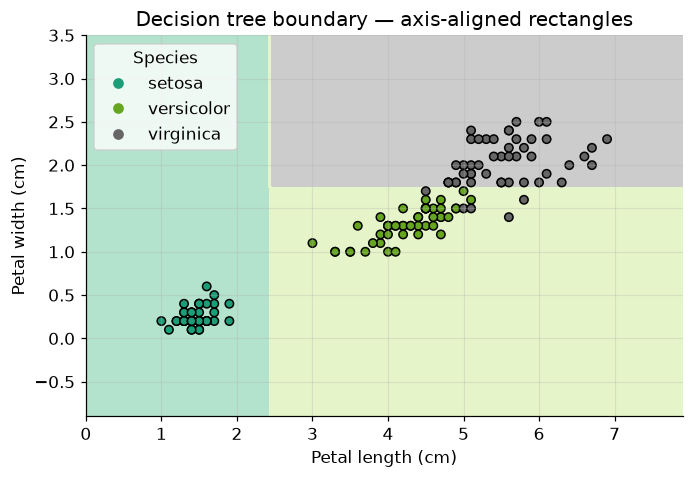

In [7]:
# Two features only, for a plottable 2-D feature space
X_petal = iris.data[:, [2, 3]]           # petal length, petal width
tree_petal = DecisionTreeClassifier(max_depth=2, random_state=42).fit(X_petal, y_ir)

fig, ax = plt.subplots()
DecisionBoundaryDisplay.from_estimator(tree_petal, X_petal, response_method="predict",
                                       multiclass_colors="Pastel2", ax=ax)
scatter = ax.scatter(X_petal[:, 0], X_petal[:, 1], c=y_ir, cmap="Dark2",
                     edgecolor="black", s=30)
ax.legend(scatter.legend_elements()[0], iris.target_names, title="Species")
ax.set_xlabel("Petal length (cm)")
ax.set_ylabel("Petal width (cm)")
ax.set_title("Decision tree boundary — axis-aligned rectangles")
plt.show()

Compare this with logistic regression's single straight (possibly diagonal) line from last module: the
tree's boundary is a set of **axis-parallel fences**. One vertical fence walls off *setosa*; one horizontal
fence splits the remaining two species. Depth 2, two fences, three regions.

Now — what happens if we *don't* cap the depth at 2? The tree will keep fencing until every training point
sits in a region of its own colour. Time to watch that go wrong.

---
## 5. Overfitting: the tree that memorized the noise

We'll stage the failure on a synthetic dataset small enough to see every point: **100 samples, 2 features,
3 classes**, generated with `make_classification` (the same tool as the admission datasets last module) —
including its default sprinkle of label noise, just like real data.

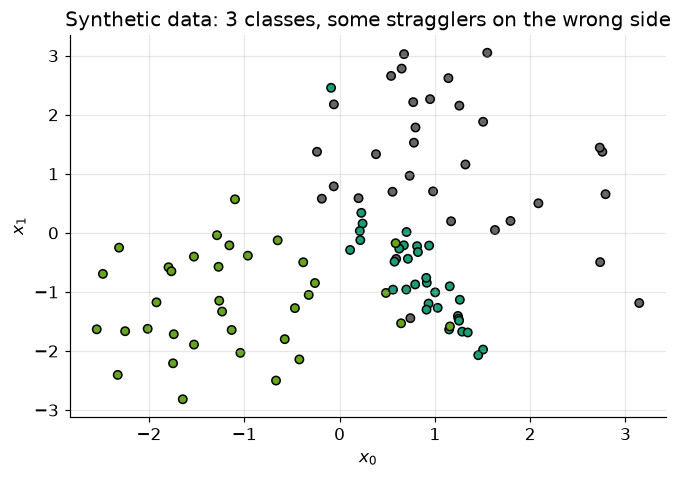

In [8]:
X_syn, y_syn = make_classification(
    n_samples=100, n_features=2, n_informative=2, n_redundant=0, n_repeated=0,
    n_classes=3, n_clusters_per_class=1, class_sep=1.0, random_state=10)

X_train, X_test, y_train, y_test = train_test_split(
    X_syn, y_syn, test_size=0.2, random_state=RANDOM_STATE)

plt.scatter(X_syn[:, 0], X_syn[:, 1], c=y_syn, cmap="Dark2", edgecolor="black", s=30)
plt.xlabel("$x_0$")
plt.ylabel("$x_1$")
plt.title("Synthetic data: 3 classes, some stragglers on the wrong side")
plt.show()

Three clouds with genuinely fuzzy borders — a few points sit deep inside a neighbouring class's
territory. Keep an eye on those stragglers.

Fit a tree with **all defaults** — which, remember from Section 3, means *grow until every leaf is pure*:

In [9]:
tree_full = DecisionTreeClassifier(random_state=RANDOM_STATE)
tree_full.fit(X_train, y_train)

print(f"Tree depth: {tree_full.get_depth()},  leaves: {tree_full.get_n_leaves()}")
print(f"Training accuracy: {tree_full.score(X_train, y_train):.1%}")
print(f"Test accuracy:     {tree_full.score(X_test, y_test):.1%}")

Tree depth: 9,  leaves: 15
Training accuracy: 100.0%
Test accuracy:     85.0%


There's the signature: **perfect on the training set, mediocre on the test set**. The tree isn't
generalizing — it's reciting. This is precisely the overfitting we met in the Regularization module, only
the complexity dial isn't polynomial degree anymore; it's **depth**. And depth is an exponential dial: a
binary tree of depth $d$ can hold up to

$$\textbf{Number of nodes} = 2^{d+1} - 1$$

so capacity roughly *doubles with every extra level*. Let's sweep the dial and watch both accuracies:

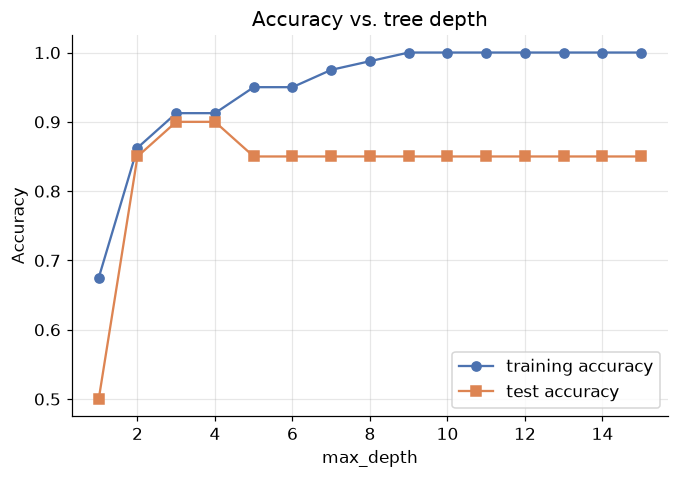

Best test accuracy: 90.0% at depth 3
Training accuracy saturates at 100% from depth 9 (the tree can't grow further — every leaf is pure).


In [10]:
max_depth_range = range(1, 16)
clfs, train_acc, test_acc = [], [], []

for d in max_depth_range:
    clf = DecisionTreeClassifier(max_depth=d, random_state=RANDOM_STATE)
    clf.fit(X_train, y_train)
    clfs.append(clf)
    train_acc.append(clf.score(X_train, y_train))
    test_acc.append(clf.score(X_test, y_test))

plt.plot(max_depth_range, train_acc, marker="o", label="training accuracy")
plt.plot(max_depth_range, test_acc, marker="s", label="test accuracy")
plt.xlabel("max_depth")
plt.ylabel("Accuracy")
plt.title("Accuracy vs. tree depth")
plt.legend()
plt.show()

best_d = max_depth_range[int(np.argmax(test_acc))]
print(f"Best test accuracy: {max(test_acc):.1%} at depth {best_d}")
print(f"Training accuracy saturates at 100% from depth {tree_full.get_depth()} "
      f"(the tree can't grow further — every leaf is pure).")

Read the two curves like a diagnosis chart:

- **Training accuracy climbs monotonically to 100%** and pins there — more depth never hurts on data you're
  allowed to memorize.
- **Test accuracy peaks early, at a shallow depth**, then drifts *down* as depth grows. Every level beyond
  the peak buys training accuracy only, by fitting noise.

The widening gap between the curves *is* overfitting, made visible. And we can make it even more visible —
let's draw the decision boundary at increasing depths and watch the fences multiply:

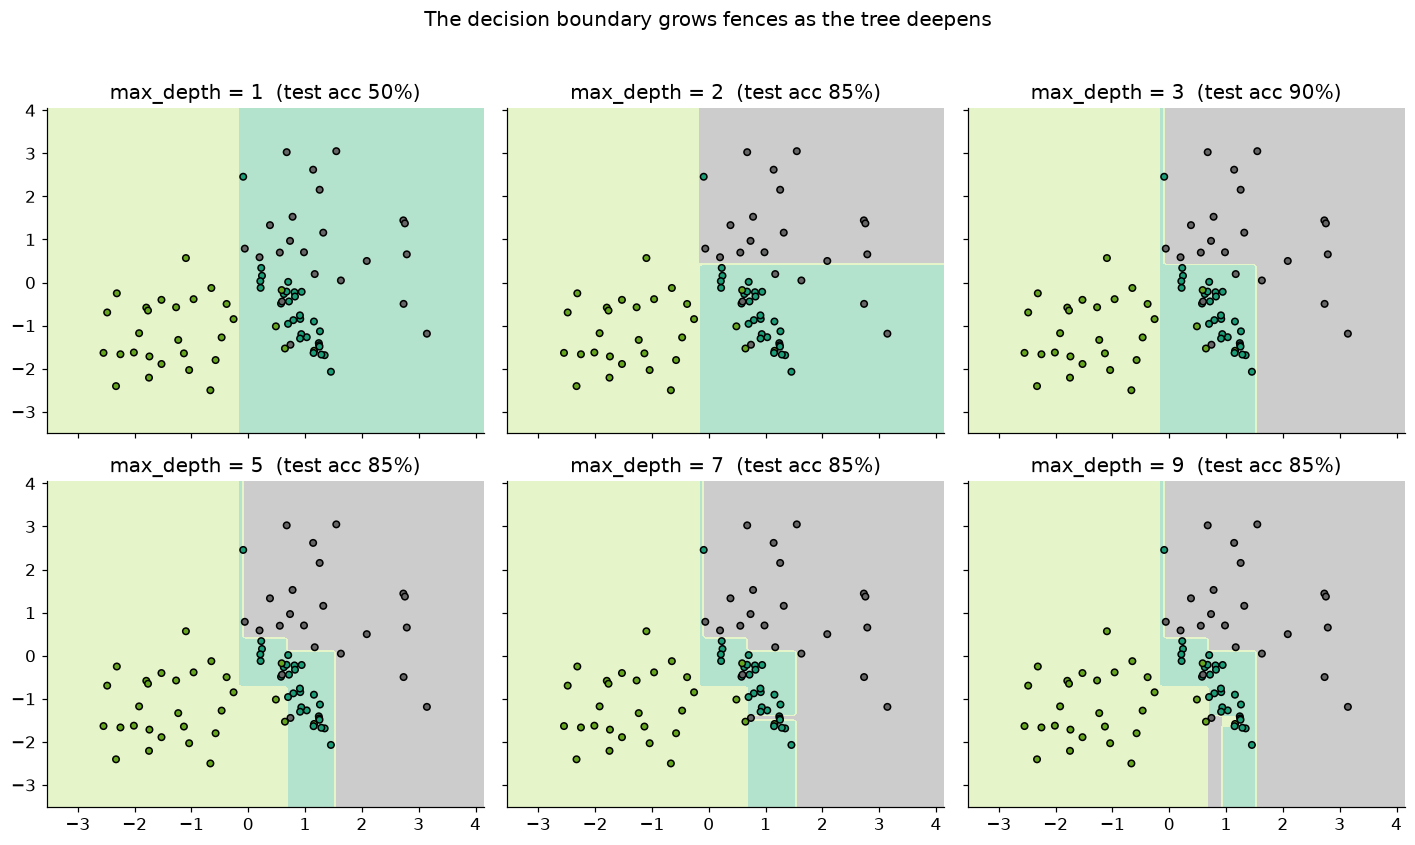

In [11]:
depths_to_show = [1, 2, 3, 5, 7, tree_full.get_depth()]
fig, axes = plt.subplots(2, 3, figsize=(13, 7.5), sharex=True, sharey=True)

for ax, d in zip(axes.ravel(), depths_to_show):
    clf = DecisionTreeClassifier(max_depth=d, random_state=RANDOM_STATE).fit(X_train, y_train)
    DecisionBoundaryDisplay.from_estimator(clf, X_train, response_method="predict",
                                           multiclass_colors="Pastel2", ax=ax)
    ax.scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap="Dark2",
               edgecolor="black", s=18)
    ax.set_title(f"max_depth = {d}  (test acc {clf.score(X_test, y_test):.0%})")
    ax.grid(False)

fig.suptitle("The decision boundary grows fences as the tree deepens", y=1.02)
plt.tight_layout()
plt.show()

At depth 1 and 2 the regions are broad and sensible. By the final panel, the tree has carved **tiny
one-point enclaves** deep inside foreign territory — a private rectangle for each straggler. Those
stragglers sit at the fuzzy class borders; they are noise, or at best unrepeatable edge cases, and the tree
has spent most of its depth budget building fences around them. New data will not repeat that noise, which
is exactly why test accuracy fell.

There's a structural reason deep trees chase noise so readily: **every split thins the data**. Each level
partitions the samples among more nodes, so decisions near the bottom rest on a handful of points —
statistically flimsy evidence for any fence:

<div align="center">
<img src="resources/images/dt_sample_size_reduction.png" width="360">

*Figure 7 — Sample size shrinks at every level; deep splits are decided by very few samples.*
</div>

### Occam's razor

Which depth should we keep, then? The accuracy sweep showed several depths sharing (or nearly sharing) the
best test accuracy. **Occam's razor** — *when multiple solutions perform alike, prefer the simplest* — says
take the shallowest of them. Simpler trees are cheaper, more interpretable, and rest their decisions on more
samples per node.

Two families of techniques put this principle into practice:

1. **Early stopping** (top-down): refuse to grow the tree past preset limits — Section 6.
2. **Pruning** (bottom-up): grow the tree fully, then cut back the branches that don't pay their way —
   Section 8. *(A third strategy — ensembles of trees, i.e. random forests — is a story for a future
   module.)*

---
## 6. Early stopping: three brakes on growth

Early stopping bolts stopping criteria onto step 2 of the growing algorithm: make a leaf not only when
pure, but also when a growth budget runs out. `DecisionTreeClassifier` exposes each budget as a
constructor argument. We'll try the three classics on our synthetic data and watch both the *tree
structure* and the *test accuracy* respond. (Baseline to beat, from Section 5: the full tree's test
accuracy.)

### Brake 1 — depth limitation (`max_depth`)

The bluntest brake: no path may exceed a fixed number of questions.

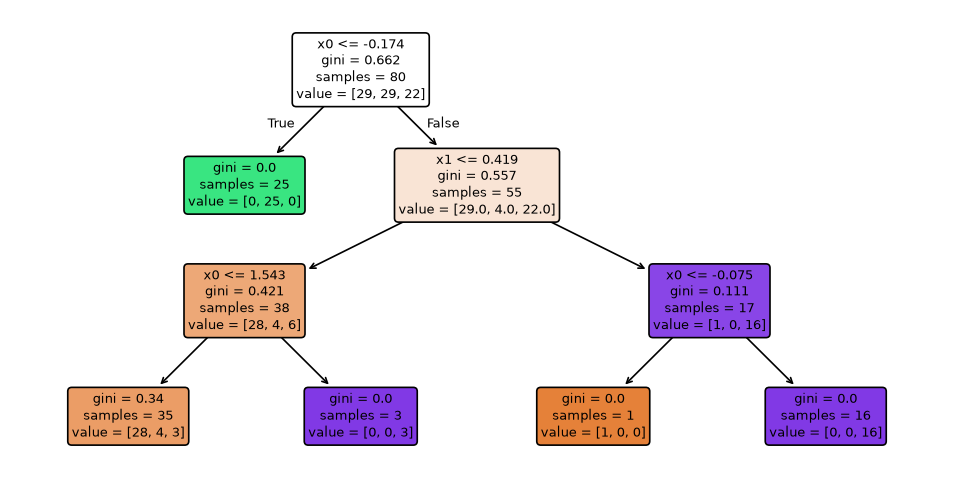

Leaves: 5   (full tree had 15)
Training accuracy: 91.2%
Test accuracy:     90.0%  (full tree: 85.0%)


In [12]:
tree_depth3 = DecisionTreeClassifier(max_depth=3, random_state=RANDOM_STATE)
tree_depth3.fit(X_train, y_train)

fig, ax = plt.subplots(figsize=(10, 5), dpi=120)
plot_tree(tree_depth3, filled=True, rounded=True, fontsize=8,
          feature_names=["x0", "x1"], ax=ax)
ax.grid(False)
plt.show()

print(f"Leaves: {tree_depth3.get_n_leaves()}   (full tree had {tree_full.get_n_leaves()})")
print(f"Training accuracy: {tree_depth3.score(X_train, y_train):.1%}")
print(f"Test accuracy:     {tree_depth3.score(X_test, y_test):.1%}  "
      f"(full tree: {tree_full.score(X_test, y_test):.1%})")

A third of the leaves, *better* test accuracy — the fences around the stragglers are gone and nothing of
value was lost. But note the leaves that are still impure: the tree wanted to keep splitting and we cut it
off mid-thought. Setting the number requires care: too low and the tree underfits; and there's no way to
know the right value in advance.

### Brake 2 — impurity threshold (`min_impurity_decrease`)

Subtler: allow a split only if it *reduces impurity by at least a threshold*. Splits with negligible
payoff are refused, wherever in the tree they occur. The impurity reduction that scikit-learn computes for
a node split is the weighted version from Section 2:

$$\Delta = \frac{m_{\text{node}}}{m}\left(\text{impurity} - \frac{m_{\text{left}}}{m_{\text{node}}}\,\text{impurity}_{\text{left}} - \frac{m_{\text{right}}}{m_{\text{node}}}\,\text{impurity}_{\text{right}}\right)$$

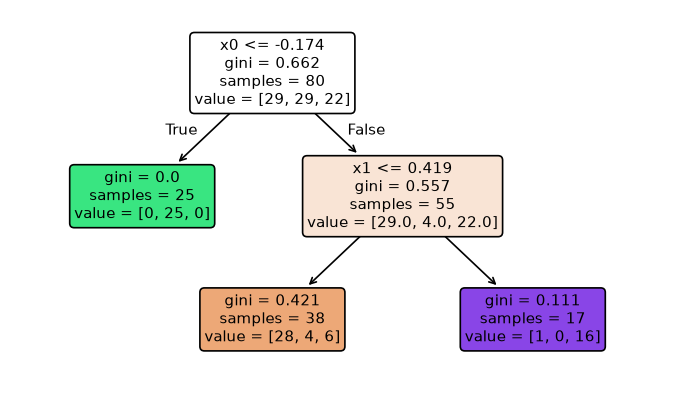

Leaves: 3
Training accuracy: 86.2%
Test accuracy:     85.0%


In [13]:
tree_impurity = DecisionTreeClassifier(min_impurity_decrease=0.1, random_state=RANDOM_STATE)
tree_impurity.fit(X_train, y_train)

fig, ax = plt.subplots(figsize=(7, 4), dpi=120)
plot_tree(tree_impurity, filled=True, rounded=True, fontsize=9,
          feature_names=["x0", "x1"], ax=ax)
ax.grid(False)
plt.show()

print(f"Leaves: {tree_impurity.get_n_leaves()}")
print(f"Training accuracy: {tree_impurity.score(X_train, y_train):.1%}")
print(f"Test accuracy:     {tree_impurity.score(X_test, y_test):.1%}")

Only the splits that pay ≥ 0.1 in impurity reduction survived — a very small tree. The remaining impure
leaves wanted to split, but each candidate split offered less than the threshold, so growth stopped there.

### Brake 3 — minimum samples to split (`min_samples_split`)

Attack the Figure-7 problem directly: **refuse to split thin nodes**. If a node holds fewer than the
minimum, it becomes a leaf regardless of purity — decisions must rest on a respectable amount of
evidence.

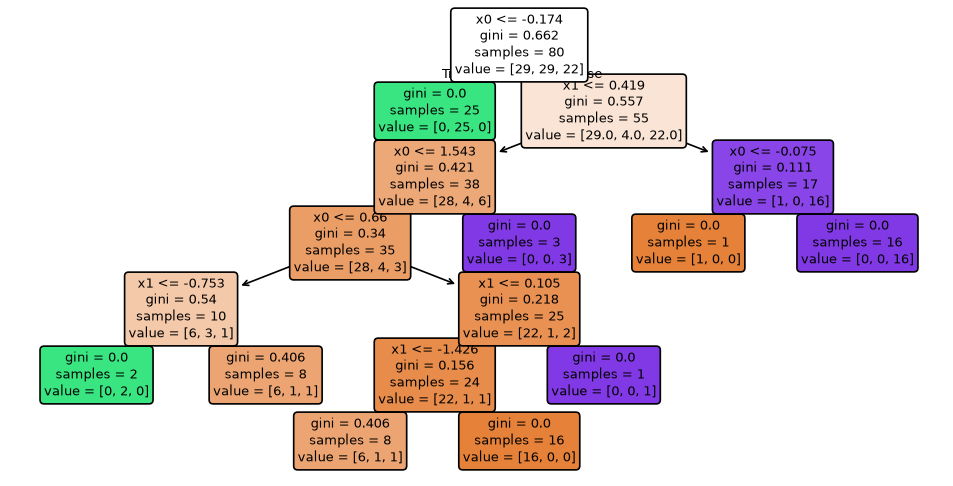

Leaves: 9
Training accuracy: 95.0%
Test accuracy:     85.0%


In [14]:
tree_minsamples = DecisionTreeClassifier(min_samples_split=10, random_state=RANDOM_STATE)
tree_minsamples.fit(X_train, y_train)

fig, ax = plt.subplots(figsize=(10, 5), dpi=120)
plot_tree(tree_minsamples, filled=True, rounded=True, fontsize=8,
          feature_names=["x0", "x1"], ax=ax)
ax.grid(False)
plt.show()

print(f"Leaves: {tree_minsamples.get_n_leaves()}")
print(f"Training accuracy: {tree_minsamples.score(X_train, y_train):.1%}")
print(f"Test accuracy:     {tree_minsamples.score(X_test, y_test):.1%}")

The tiny nodes (fewer than 10 samples) stopped splitting; note this brake has **no direct grip on depth**
— a well-populated branch may still grow deep.

### The catch, in all three cases

Every brake needed a *number* — 3, 0.1, 10 — and we set each **before training, essentially by guessing**.
Set it too aggressive and the tree underfits; too lenient and overfitting returns. On this dataset,
`max_depth=3` happened to work nicely — but we only know that because we peeked at test accuracy
afterwards. Worse, early stopping has a structural blind spot, which the next section demonstrates with a
famously nasty four-point dataset.

---
## 7. When early stopping fails: the XOR problem

The **XOR** (exclusive-or) dataset is four points: the label is 1 when *exactly one* of the two features
is 1.

| $x_1$ | $x_2$ | $y$ |
|---|---|---|
| 0 | 0 | 0 |
| 0 | 1 | 1 |
| 1 | 0 | 1 |
| 1 | 1 | 0 |

The trap: **no single split helps**. Cut on $x_1$ (or $x_2$) and each child still holds one 0 and one 1 —
impurity doesn't budge. The first question is worthless *on its own*; it only pays off in combination with
the second. Watch what an impurity-threshold brake does here — we demand a tiny minimum reduction of just
0.01:

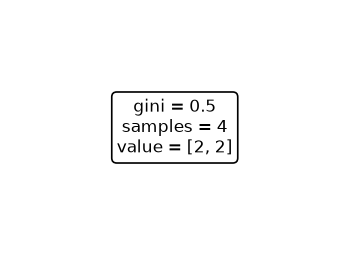

Nodes: 1 — the tree refused to grow at all.
Training accuracy: 50%


In [15]:
# The XOR dataset
X_xor = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
y_xor = np.array([0, 1, 1, 0])

tree_xor_stopped = DecisionTreeClassifier(min_impurity_decrease=0.01, random_state=RANDOM_STATE)
tree_xor_stopped.fit(X_xor, y_xor)

fig, ax = plt.subplots(figsize=(3.5, 2.5), dpi=120)
plot_tree(tree_xor_stopped, filled=True, rounded=True, fontsize=10,
          feature_names=["x1", "x2"], ax=ax)
ax.grid(False)
plt.show()
print(f"Nodes: {tree_xor_stopped.tree_.node_count} — the tree refused to grow at all.")
print(f"Training accuracy: {tree_xor_stopped.score(X_xor, y_xor):.0%}")

A single node — a stump. The first split reduces impurity by (essentially) zero, that's below our
threshold, so the brake slammed on *at the root*. The model predicts one class for everything: coin-flip
accuracy on a dataset that is **perfectly learnable**. Remove the brake:

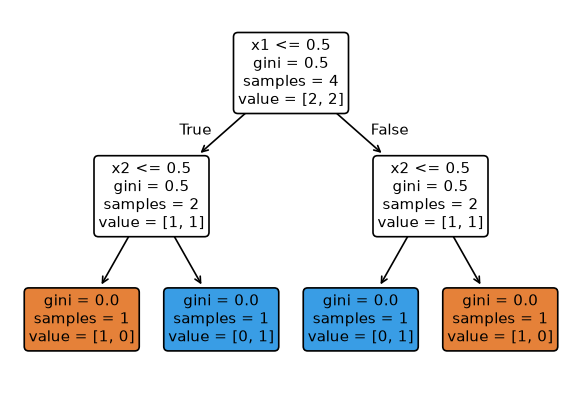

Nodes: 7
Training accuracy: 100%


In [16]:
tree_xor_full = DecisionTreeClassifier(random_state=RANDOM_STATE)
tree_xor_full.fit(X_xor, y_xor)

fig, ax = plt.subplots(figsize=(6, 4), dpi=120)
plot_tree(tree_xor_full, filled=True, rounded=True, fontsize=9,
          feature_names=["x1", "x2"], ax=ax)
ax.grid(False)
plt.show()
print(f"Nodes: {tree_xor_full.tree_.node_count}")
print(f"Training accuracy: {tree_xor_full.score(X_xor, y_xor):.0%}")

Allowed to make that first "useless" split, the tree solves XOR perfectly two levels later. Look at the
root's children: the first split bought *zero* impurity reduction, exactly as predicted — but it set up
the second round of splits that finish the job.

This is the **horizon effect**: early stopping judges each split by its *immediate* payoff, but some splits
only pay off one level beyond the horizon. A greedy brake can't see that far. The remedy is to stop
judging splits on the way down, and instead judge *finished subtrees* on the way back up: grow the whole
tree first, then remove the parts that didn't earn their keep. That is **pruning**.

---
## 8. Pruning: grow first, cut later

Pruning inverts early stopping's philosophy. **Grow the tree to its entirety — noise fences, XOR detours
and all — then remove the branches that don't justify their complexity.** Because judgment happens after
the fact, a branch that looked useless at birth (XOR's first split) but proved essential gets kept, while
a branch that fenced one noisy point gets cut.

Of the several pruning techniques in the literature (reduced-error pruning, minimum-error pruning,
error-based pruning…), we focus on the most widely used — the one scikit-learn implements:
**cost-complexity pruning**, from the CART family.

### The idea: put a price on leaves

Cost-complexity pruning scores a tree $T$ by its error *plus rent on its size*:

$$R_\alpha(T) = R(T) + \alpha \, |T|$$

where $R(T)$ is the tree's total impurity-weighted error on the training data, $|T|$ is its number of
leaves, and $\alpha \geq 0$ is the **price per leaf**. If this looks familiar, it should — it is *exactly*
the regularization pattern from the Regularization module: $\text{cost} = \text{fit} + \lambda \cdot
\text{complexity}$, with leaves in place of coefficients.

- $\alpha = 0$: leaves are free → the fully grown tree wins.
- $\alpha \to \infty$: leaves are ruinous → a single-node stump wins.
- In between, each $\alpha$ picks out one best sub-tree.

### The weakest link

Which branch goes first as $\alpha$ rises? For each internal node $t$, ask: how much error does its
subtree save us, per extra leaf it costs? The break-even price is

$$\alpha_{\text{eff}}(t) = \frac{R(t) - R(T_t)}{|T_t| - 1}$$

where $R(t)$ is the error if node $t$ were collapsed to a leaf, and $R(T_t)$, $|T_t|$ are the error and
leaf-count of the subtree hanging from $t$. The node with the **smallest** $\alpha_{\text{eff}}$ — the
*weakest link* — is the worst deal in the tree, and is pruned first. Collapsing weakest links one after
another produces a nested sequence of ever-simpler trees:

<div align="center">
<img src="resources/images/dt_pruning_sequence.png" width="620">

*Figure 8 — Sequential pruning: collapse the weakest link (red), rescore, repeat, down to the root.*
</div>

**A worked $\alpha_{\text{eff}}$.** Take the subtree below (from a tree trained on 80 samples), rooted at
node #4:

<div align="center">
<img src="resources/images/dt_alpha_subtree.png" width="300">

*Figure 9 — A candidate for pruning: node #4 and its two leaves.*
</div>

With impurity-weighted error $R = \text{gini} \times \frac{\text{samples}}{\text{total}}$:

- Collapsed: $R(t) = 0.245 \times \frac{29}{80} \approx 0.0888$
- Kept: $R(T_t) = \underbrace{0.594 \times \tfrac{8}{80}}_{\text{node \#5}} + \underbrace{0.0 \times \tfrac{21}{80}}_{\text{node \#6}} \approx 0.0594$, with $|T_t| = 2$ leaves

$$\alpha_{\text{eff}} = \frac{0.0888 - 0.0594}{2 - 1} \approx 0.0294$$

If the price per leaf rises above 0.0294, this subtree stops being worth its rent and is collapsed.

### Doing it in scikit-learn

`cost_complexity_pruning_path` runs the weakest-link procedure and returns every break-even $\alpha$ —
the full menu of candidate trees. The parameter `ccp_alpha` then trains a tree pruned at a given price:

In [17]:
tree_for_path = DecisionTreeClassifier(random_state=RANDOM_STATE)
path = tree_for_path.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas = path.ccp_alphas

print("Break-even alphas (one per candidate tree):")
print(np.round(ccp_alphas, 5))

Break-even alphas (one per candidate tree):
[0.      0.01071 0.0125  0.01272 0.01562 0.02036 0.02353 0.05143 0.1592
 0.27884]


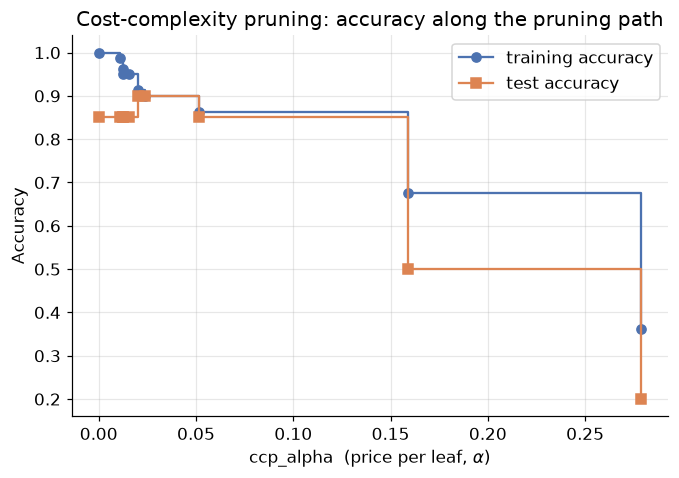

alpha=0.0000  leaves=15  depth=9  train=1.00  test=0.85
alpha=0.0107  leaves=13  depth=8  train=0.99  test=0.85
alpha=0.0125  leaves=11  depth=7  train=0.96  test=0.85
alpha=0.0127  leaves= 9  depth=6  train=0.95  test=0.85
alpha=0.0156  leaves= 8  depth=5  train=0.95  test=0.85
alpha=0.0204  leaves= 5  depth=3  train=0.91  test=0.90
alpha=0.0235  leaves= 4  depth=3  train=0.90  test=0.90
alpha=0.0514  leaves= 3  depth=2  train=0.86  test=0.85
alpha=0.1592  leaves= 2  depth=1  train=0.68  test=0.50
alpha=0.2788  leaves= 1  depth=0  train=0.36  test=0.20


In [18]:
# One tree per alpha, scored on train and test
pruned_trees = [DecisionTreeClassifier(random_state=RANDOM_STATE, ccp_alpha=a).fit(X_train, y_train)
                for a in ccp_alphas]
train_scores = [t.score(X_train, y_train) for t in pruned_trees]
test_scores = [t.score(X_test, y_test) for t in pruned_trees]

plt.step(ccp_alphas, train_scores, marker="o", where="post", label="training accuracy")
plt.step(ccp_alphas, test_scores, marker="s", where="post", label="test accuracy")
plt.xlabel(r"ccp_alpha  (price per leaf, $\alpha$)")
plt.ylabel("Accuracy")
plt.title("Cost-complexity pruning: accuracy along the pruning path")
plt.legend()
plt.show()

for a, t, tr, te in zip(ccp_alphas, pruned_trees, train_scores, test_scores):
    print(f"alpha={a:.4f}  leaves={t.get_n_leaves():2d}  depth={t.get_depth()}  "
          f"train={tr:.2f}  test={te:.2f}")

Read the table right to left is also instructive, but the headline reads left to right: as $\alpha$
rises, leaves fall away, training accuracy erodes gently — and **test accuracy actually climbs** before
collapsing when pruning starts amputating real structure. The best test accuracy is shared by more than
one $\alpha$; **Occam's razor says take the largest of them** (the smallest tree). Let's select it
programmatically and look at the survivor:

Chosen alpha: 0.0235
Pruned tree:  4 leaves, depth 3 (full tree: 15 leaves, depth 9)
Test accuracy: 90.0% (full tree: 85.0%)


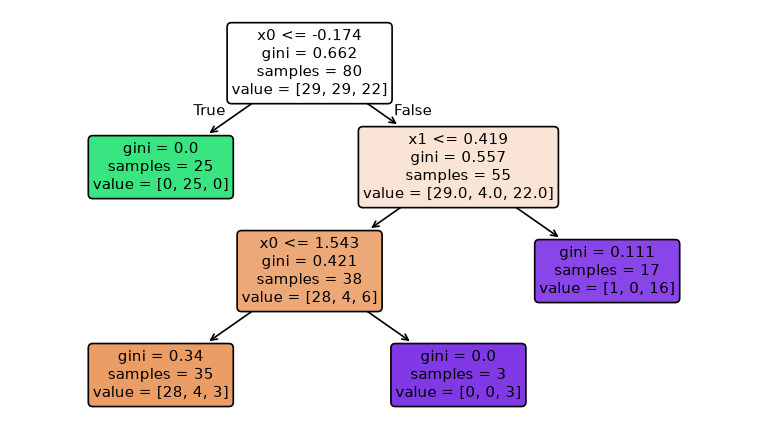

In [19]:
best = max(range(len(ccp_alphas)),
           key=lambda i: (test_scores[i], ccp_alphas[i]))   # best test acc, ties -> larger alpha
best_alpha = ccp_alphas[best]
tree_pruned = pruned_trees[best]

print(f"Chosen alpha: {best_alpha:.4f}")
print(f"Pruned tree:  {tree_pruned.get_n_leaves()} leaves, depth {tree_pruned.get_depth()} "
      f"(full tree: {tree_full.get_n_leaves()} leaves, depth {tree_full.get_depth()})")
print(f"Test accuracy: {tree_pruned.score(X_test, y_test):.1%} "
      f"(full tree: {tree_full.score(X_test, y_test):.1%})")

fig, ax = plt.subplots(figsize=(8, 4.5), dpi=120)
plot_tree(tree_pruned, filled=True, rounded=True, fontsize=9,
          feature_names=["x0", "x1"], ax=ax)
ax.grid(False)
plt.show()

From fifteen leaves to a handful, *and* better test accuracy. Compare how we got here with Section 6:
early stopping asked us to guess magic numbers before training; pruning **derived its candidate
$\alpha$ values from the tree itself** and let held-out accuracy pick among them. That is why pruning —
specifically cost-complexity pruning with the $\alpha$ grid from `cost_complexity_pruning_path` — is the
standard recommendation. (In a production workflow you'd pick $\alpha$ on a *validation* split or by
cross-validation, keeping the test set untouched for the final report — the protocol from the ML Workflow
module.)

---
## 9. A short history: ID3, C4.5, CART

"Decision tree" is a family, not a single algorithm. The members — called **inducers** — differ in which
impurity metric they optimize, what data they accept, and how they fight overfitting. Three names matter:

- **ID3** (*Iterative Dichotomiser 3*, Ross Quinlan): the original. Splits on **information gain**,
  multiway splits on categorical attributes only, **no pruning** — so it inherits both of information
  gain's flaws we met in Section 2 (the ID-column bias) and this module's disease (overfitting).
- **C4.5** (Quinlan again): the fix-up release. Splits on **gain ratio** (Section 2's correction), handles
  **continuous attributes** by thresholding them, tolerates missing values, and prunes (error-based
  pruning).
- **CART** (*Classification and Regression Trees*, Breiman et al.): strictly **binary** splits, **Gini**
  (classification) or **MSE/variance** (regression), **cost-complexity pruning** — Section 8. Because it
  covers regression too, it is the most versatile, and it is the algorithm behind scikit-learn's
  `DecisionTreeClassifier` and `DecisionTreeRegressor` (an optimized version of it).

<div align="center">
<img src="resources/images/dt_inducers_table.png" width="700">

*Figure 10 — The three classic inducers at a glance.*
</div>

(That "CART builds binary trees" detail explains a curiosity from Section 7: on the XOR data, the learned
thresholds appear as $x_1 \le 0.5$ even though the feature only takes values 0 and 1 — CART always cuts a
continuous range at a midpoint between observed values.)

---
## 10. Finishing the evaluation toolkit

Last module gave us the confusion matrix, precision, recall, and F1 — for **two classes** and a **fixed
threshold**. Both restrictions come off now.

### 10.1 The confusion matrix goes multiclass

For $K$ classes the confusion matrix is $K \times K$; here is one for a hypothetical fruit classifier:

<div align="center">
<img src="resources/images/dt_multiclass_cm.png" width="400">

*Figure 11 — A 3-class confusion matrix (columns: actual, rows: predicted). The diagonal holds the correct
predictions.*
</div>

TP, FP, FN, TN are now defined *per class*. For the class **Apple**: TP is the Apple-Apple cell; FP is the
rest of Apple's *predicted* row (called Apple, was something else); FN is the rest of Apple's *actual*
column (was Apple, called something else); TN is everything remaining:

<div align="center">
<img src="resources/images/dt_multiclass_cm_apple.png" width="440">

*Figure 12 — TP / FP / FN / TN from the class Apple's point of view.*
</div>

With per-class TP/FP/FN in hand, precision, recall, and F1 follow for each class exactly as in the binary
case:

<div align="center">
<img src="resources/images/dt_multiclass_prf.png" width="330">

*Figure 13 — Per-class precision, recall, and F1 for the fruit classifier.*
</div>

Three F1 scores for three classes — but a leaderboard needs *one* number. Three standard ways to average
(imagine 1000 classes and the need becomes obvious):

- **Macro F1** — the plain mean of per-class F1 scores. Every class counts equally, so rare classes weigh
  as much as common ones.
- **Weighted F1** — the mean weighted by each class's number of true instances (*support*). Big classes
  dominate.
- **Micro F1** — pool TP, FP, FN over all classes *first*, then compute F1 from the totals. For
  single-label classification this equals plain accuracy.

Scikit-learn exposes all three through the `average` parameter — and its `classification_report` (which we
read for two classes last module) simply grows one row per class. Let's evaluate our pruned iris tree
properly:

In [20]:
y_ir_pred = tree_iris.predict(X_ir_test)

print(classification_report(y_ir_test, y_ir_pred, target_names=iris.target_names))

for avg in ["macro", "weighted", "micro"]:
    print(f"{avg:>9} F1: {f1_score(y_ir_test, y_ir_pred, average=avg):.4f}")
print(f"{'accuracy':>9}   : {accuracy_score(y_ir_test, y_ir_pred):.4f}   (= micro F1)")

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30

    macro F1: 0.9333
 weighted F1: 0.9333
    micro F1: 0.9333
 accuracy   : 0.9333   (= micro F1)


On iris the three averages barely differ, because the classes are balanced and similarly easy. They
diverge on *imbalanced* problems: macro F1 punishes a model that dumps its rare classes; weighted F1
forgives it. Choose deliberately — it is the multiclass version of last module's "metric choice is a
modelling decision".

### 10.2 Metrics across all thresholds: PR curves, ROC, and AUC

Every metric so far was computed **at one threshold** (0.5 by default). But last module's Exercise 2
showed the threshold is a *free dial*: lower it and recall rises while precision falls; raise it and the
reverse. One threshold = one (precision, recall) pair:

<div align="center">
<img src="resources/images/dt_threshold_table.png" width="640">

*Figure 14 — Six students, four thresholds: each threshold yields a different precision/recall pair.*
</div>

Sweep the threshold over its whole range, plot every pair, and you get the **precision–recall curve** —
the complete menu of trade-offs a classifier offers. The closer it hugs the top-right corner (precision
*and* recall high), the better the classifier:

<div align="center">
<img src="resources/images/dt_pr_curve.png" width="380">

*Figure 15 — A typical precision–recall curve; each point is one threshold.*
</div>

The **ROC curve** (*Receiver Operating Characteristic*) applies the same sweep to a different pair of
axes:

$$\text{TPR} = \frac{TP}{TP + FN} \;(= \text{recall}), \qquad \text{FPR} = \frac{FP}{FP + TN}$$

— the benefit (catching positives) against the collateral damage (false alarms among the negatives). Three
reference shapes to calibrate your eye:

<div align="center">
<img src="resources/images/dt_roc_curves.png" width="700">

*Figure 16 — ROC curves: a perfect classifier hugs the top-left corner; a random one lies on the diagonal;
real classifiers live in between.*
</div>

Squashing the whole curve into one number gives the **AUC** (*Area Under the Curve*): 1.0 for a perfect
classifier, 0.5 for coin-flipping. AUC measures ranking quality across *all* thresholds at once, which
makes it ideal for comparing models before you've committed to an operating point.

### 10.3 The rematch: decision tree vs. logistic regression

Let's put the module together. Same diabetes data as last module, two challengers — our new pruned tree
against the reigning logistic regression — judged on ROC curves and AUC:

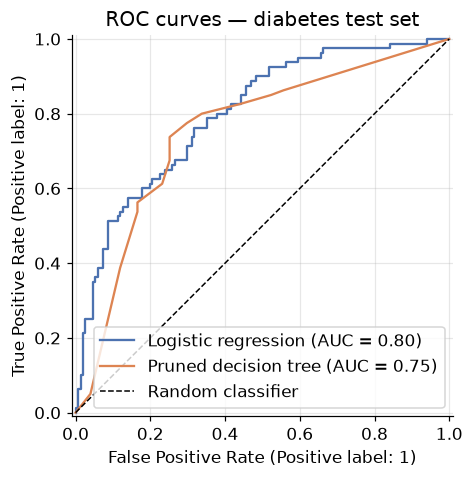

Logistic regression    AUC = 0.798


Pruned decision tree   AUC = 0.752


In [21]:
X_diab = diabetes.drop("Outcome", axis=1)
y_diab = diabetes["Outcome"]
Xd_train, Xd_test, yd_train, yd_test = train_test_split(
    X_diab, y_diab, test_size=0.3, random_state=42)

# Challenger 1: logistic regression (scaled, as always)
logreg_diab = make_pipeline(StandardScaler(), LogisticRegression())
logreg_diab.fit(Xd_train, yd_train)

# Challenger 2: a cost-complexity-pruned decision tree (alpha chosen on the training data's path)
path_d = DecisionTreeClassifier(random_state=RANDOM_STATE).cost_complexity_pruning_path(Xd_train, yd_train)
tree_diab = DecisionTreeClassifier(random_state=RANDOM_STATE,
                                   ccp_alpha=0.005)   # a mid-path value; tune it in Exercise 5
tree_diab.fit(Xd_train, yd_train)

fig, ax = plt.subplots()
RocCurveDisplay.from_estimator(logreg_diab, Xd_test, yd_test, name="Logistic regression", ax=ax)
RocCurveDisplay.from_estimator(tree_diab, Xd_test, yd_test, name="Pruned decision tree", ax=ax)
ax.plot([0, 1], [0, 1], "k--", linewidth=1, label="Random classifier")
ax.set_title("ROC curves — diabetes test set")
ax.legend()
plt.show()

for name, model in [("Logistic regression", logreg_diab), ("Pruned decision tree", tree_diab)]:
    auc = roc_auc_score(yd_test, model.predict_proba(Xd_test)[:, 1])
    print(f"{name:<22} AUC = {auc:.3f}")

Both classifiers sit well above the random diagonal, with logistic regression's smooth probability
ranking typically edging out the tree's chunkier one (a tree only outputs as many distinct probability
values as it has leaves — hence its staircase ROC). The precision–recall view tells the same story with an
imbalanced-data accent:

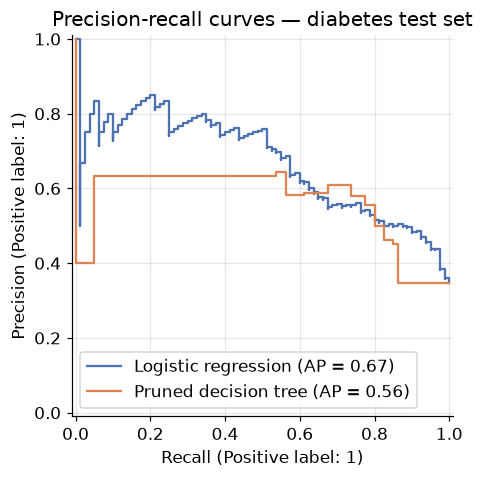

In [22]:
fig, ax = plt.subplots()
PrecisionRecallDisplay.from_estimator(logreg_diab, Xd_test, yd_test, name="Logistic regression", ax=ax)
PrecisionRecallDisplay.from_estimator(tree_diab, Xd_test, yd_test, name="Pruned decision tree", ax=ax)
ax.set_title("Precision-recall curves — diabetes test set")
plt.show()

So which model *should* a clinic deploy? The AUC verdict favours one; but the tree can be printed on one
page and audited by a doctor, gets no benefit from feature scaling (its thresholds are scale-invariant —
notice we never scaled its inputs), and handles the mixed-scale features natively. Model choice, like
metric choice, is a decision about *what matters in the domain* — you now have the tools to make both
honestly.

---
## 11. Your turn

Add cells below each exercise. Exercises 3 and 5 consolidate the big ideas.

**Exercise 1 — The other question.**
In the Section 2 loan example, compute the information gain for splitting on *Is Married* (row 1 goes one
way, rows 2–4 the other). Compare with the *Is House Owner* gain we computed. Which question should the
tree ask first?

**Exercise 2 — Gini vs. entropy, empirically.**
Refit the Section 5 full tree with `criterion="entropy"` and compare depth, leaf count, and test accuracy
against the Gini default. Do the two impurity metrics disagree much here?

**Exercise 3 — The overfitting autopsy.**
Take the full tree from Section 5 and find a leaf with `samples = 1` (use the tree plot, or explore
`tree_full.tree_.n_node_samples`). Locate that training point in the scatter plot. Is it a straggler inside
another class's territory? Explain in two sentences why the pruned tree of Section 8 classifies that
*region* differently — and why that's a good thing.

**Exercise 4 — Regression trees exist too.**
Load the Advertising data from the Regression module (`data/Advertising.csv`) and fit a
`DecisionTreeRegressor` (criterion: MSE) predicting sales from TV spend, with `max_depth` 2, 5, and None.
Plot the three prediction curves over a scatter of the data. Where does the regression version of
overfitting show up?

**Exercise 5 — Prune the diabetes tree properly.**
In Section 10.3 we set `ccp_alpha=0.005` by fiat. Do it right: split the *training* data further into
train/validation, evaluate every alpha from `cost_complexity_pruning_path` on the validation split, select
the winner Occam-style, and report the final model's AUC on the untouched test set. Did the rematch verdict
change?

---
## 12. If you remember nothing else

1. **A decision tree classifies by routing**: a cascade of one-feature threshold tests from root to leaf.
   Its boundary is axis-aligned rectangles; its superpower is that humans can read the fitted model.

2. **Impurity is the currency of tree-growing.** Gini ($1 - \sum P_i^2$) and entropy
   ($-\sum P_i \log_2 P_i$) are both zero for pure nodes and maximal at even mixing; splits are chosen to
   maximize the (weighted) impurity drop. Gain ratio divides by split information to stop many-valued
   attributes from cheating. Regression trees swap in MSE.

3. **Fully grown trees overfit, structurally.** Node capacity doubles per level ($2^{d+1}-1$), samples per
   node shrink per level, and growth stops only at purity — so noise gets a private fence. Signature:
   perfect training accuracy, decaying test accuracy.

4. **Early stopping** (`max_depth`, `min_impurity_decrease`, `min_samples_split`) is guesswork set before
   training, and its greedy horizon is blind to splits that pay off later — XOR defeats it at the root.

5. **Cost-complexity pruning** grows fully, then charges rent per leaf ($R_\alpha = R + \alpha|T|$ — the
   regularization pattern again), collapsing weakest links to build an $\alpha$-indexed menu of subtrees;
   pick by held-out accuracy, break ties with **Occam's razor**.

6. **ID3 → C4.5 → CART**: information gain → gain ratio → Gini/MSE with binary splits and cost-complexity
   pruning. Scikit-learn's trees are optimized CART.

7. **Multiclass F1 comes in macro / weighted / micro flavours** (equal-class, size-weighted, pooled —
   micro = accuracy); **PR and ROC curves** show a classifier at *every* threshold, and **AUC** condenses
   ranking quality into one comparable number: 1.0 perfect, 0.5 random.

---
## 13. Further reading and glossary

### Further reading

- Tan, Steinbach, Karpatne & Kumar, *Introduction to Data Mining* —
  [Chapter 4 (PDF)](https://www-users.cs.umn.edu/~kumar001/dmbook/ch4.pdf): decision trees, impurity
  metrics, and model evaluation in depth.
- Rokach & Maimon, [*Decision Trees* (PDF)](http://www.ise.bgu.ac.il/faculty/liorr/hbchap9.pdf) — the
  survey chapter: inducers (§8) and the full menagerie of pruning techniques (§6).
- scikit-learn's [Decision Trees guide](https://scikit-learn.org/stable/modules/tree.html) — including
  §"Tips on practical use" and
  [minimal cost-complexity pruning](https://scikit-learn.org/stable/auto_examples/tree/plot_cost_complexity_pruning.html).
- Terence Parr & Prince Grover, [How to visualize decision trees](https://explained.ai/decision-tree-viz/) —
  beautiful and instructive tree renderings.
- Aurélien Géron, *Hands-On Machine Learning* — Chapter 6 (trees, CART, regularization hyperparameters)
  and Chapter 3 (ROC/AUC, PR curves).

### Glossary

| Term | Meaning |
|---|---|
| **Root / internal / leaf node** | First test / subsequent tests / terminal verdict of a tree |
| **Depth** | Longest root-to-leaf path; capacity grows as $2^{d+1}-1$ nodes |
| **Impurity** | How mixed a node's classes are; 0 = pure |
| **Gini impurity** | $1-\sum P_i^2$; scikit-learn's default split criterion |
| **Entropy / information gain** | $-\sum P_i\log_2 P_i$; gain = entropy drop from a split |
| **Gain ratio** | Information gain ÷ split information; C4.5's fix for many-valued attributes |
| **Recursive partitioning** | Greedy grow-split-recurse algorithm behind all tree inducers |
| **Early stopping** | Pre-set growth limits (depth, impurity threshold, min samples) |
| **Horizon effect** | Greedy stopping misses splits whose payoff comes a level later (XOR) |
| **Cost-complexity pruning** | Grow fully, then minimize $R(T)+\alpha\lvert T\rvert$; CART's pruning |
| **Weakest link** | Node with smallest $\alpha_{\text{eff}}$; pruned first as $\alpha$ rises |
| **Occam's razor** | Among equally good models, prefer the simplest |
| **ID3 / C4.5 / CART** | The classic inducers; sklearn implements optimized CART |
| **Macro / weighted / micro F1** | Averaging schemes for multiclass F1 (micro = accuracy) |
| **ROC curve / AUC** | TPR vs. FPR across all thresholds / area under it (1 perfect, 0.5 random) |
| **Precision-recall curve** | Precision vs. recall across all thresholds |